# Telco Customer Churn Prediction — Agentic Retention Workflow

## Task 2a: Data Preparation

In [1]:
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None)


### Dataset Preview

In [2]:
df = pd.read_csv('../data/Telco-Customer-Churn.csv')
df.shape


(7043, 21)

In [3]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.describe(include='all')

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,3,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


In [6]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Data Quality Issues

In [7]:
df.isnull().sum()


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [8]:
# TotalCharges is object dtype; check for non-numeric/blank entries
pd.to_numeric(df['TotalCharges'], errors='coerce').isnull().sum()


11

In [9]:
df.loc[pd.to_numeric(df['TotalCharges'], errors='coerce').isnull(), ['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']]


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,
753,3115-CZMZD,0,20.25,
936,5709-LVOEQ,0,80.85,
1082,4367-NUYAO,0,25.75,
1340,1371-DWPAZ,0,56.05,
3331,7644-OMVMY,0,19.85,
3826,3213-VVOLG,0,25.35,
4380,2520-SGTTA,0,20.00,
5218,2923-ARZLG,0,19.70,
6670,4075-WKNIU,0,73.35,


In [10]:
df.duplicated().sum()


0

In [11]:
df['customerID'].is_unique


True

In [12]:
cat_cols = df.select_dtypes(include='object').columns
{col: [v for v in df[col].unique() if isinstance(v, str) and v != v.strip()] for col in cat_cols}


{'customerID': [],
 'gender': [],
 'Partner': [],
 'Dependents': [],
 'PhoneService': [],
 'MultipleLines': [],
 'InternetService': [],
 'OnlineSecurity': [],
 'OnlineBackup': [],
 'DeviceProtection': [],
 'TechSupport': [],
 'StreamingTV': [],
 'StreamingMovies': [],
 'Contract': [],
 'PaperlessBilling': [],
 'PaymentMethod': [],
 'TotalCharges': [' '],
 'Churn': []}

### Data Cleaning & Preprocessing

In [13]:
df_clean = df.copy()

# Blank TotalCharges corresponds to tenure == 0 (new customers, no billing cycle yet) -> impute as 0
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')
df_clean['TotalCharges'] = df_clean['TotalCharges'].fillna(0)


In [14]:
# customerID is a unique identifier, not predictive -> drop
df_clean = df_clean.drop(columns=['customerID'])


In [15]:
df_clean['SeniorCitizen'] = df_clean['SeniorCitizen'].astype('category')


In [16]:
for col in df_clean.select_dtypes(include='object').columns:
    df_clean[col] = df_clean[col].str.strip()


### Final Prepared Dataset

In [17]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   gender            7043 non-null   object  
 1   SeniorCitizen     7043 non-null   category
 2   Partner           7043 non-null   object  
 3   Dependents        7043 non-null   object  
 4   tenure            7043 non-null   int64   
 5   PhoneService      7043 non-null   object  
 6   MultipleLines     7043 non-null   object  
 7   InternetService   7043 non-null   object  
 8   OnlineSecurity    7043 non-null   object  
 9   OnlineBackup      7043 non-null   object  
 10  DeviceProtection  7043 non-null   object  
 11  TechSupport       7043 non-null   object  
 12  StreamingTV       7043 non-null   object  
 13  StreamingMovies   7043 non-null   object  
 14  Contract          7043 non-null   object  
 15  PaperlessBilling  7043 non-null   object  
 16  PaymentMethod     7043 n

In [18]:
df_clean.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [19]:
df_clean.to_csv('../data/cleaned_telco.csv', index=False)


## Task 2b: Exploratory Data Analysis

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (10, 6)
PALETTE = {'No': '#4C72B0', 'Yes': '#DD8452'}


In [21]:
df_clean = pd.read_csv('../data/cleaned_telco.csv')
df_clean['SeniorCitizen'] = df_clean['SeniorCitizen'].astype('category')
df_clean.shape


(7043, 20)

### Churn Distribution

C:\Users\amriy\AppData\Local\Temp\ipykernel_33712\1904677821.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='Churn', order=['No', 'Yes'], palette=PALETTE, ax=axes[0])


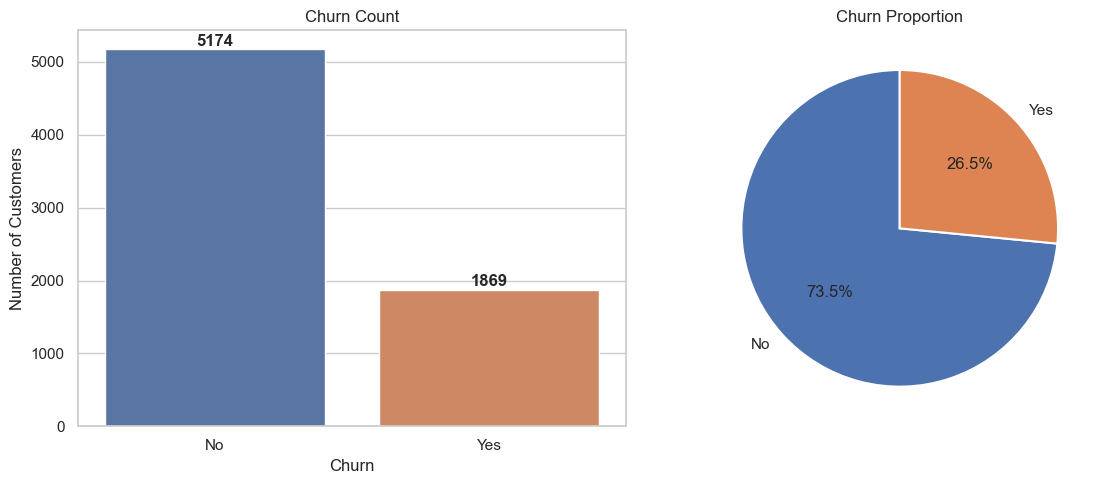

In [22]:
churn_counts = df_clean['Churn'].value_counts()
churn_pct = df_clean['Churn'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(data=df_clean, x='Churn', order=['No', 'Yes'], palette=PALETTE, ax=axes[0])
axes[0].set_title('Churn Count')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Number of Customers')
for i, v in enumerate(churn_counts.reindex(['No', 'Yes'])):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

axes[1].pie(churn_pct.reindex(['No', 'Yes']), labels=['No', 'Yes'], autopct='%1.1f%%',
            colors=[PALETTE['No'], PALETTE['Yes']], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Churn Proportion')

plt.tight_layout()
plt.show()


### Numeric Feature Distributions

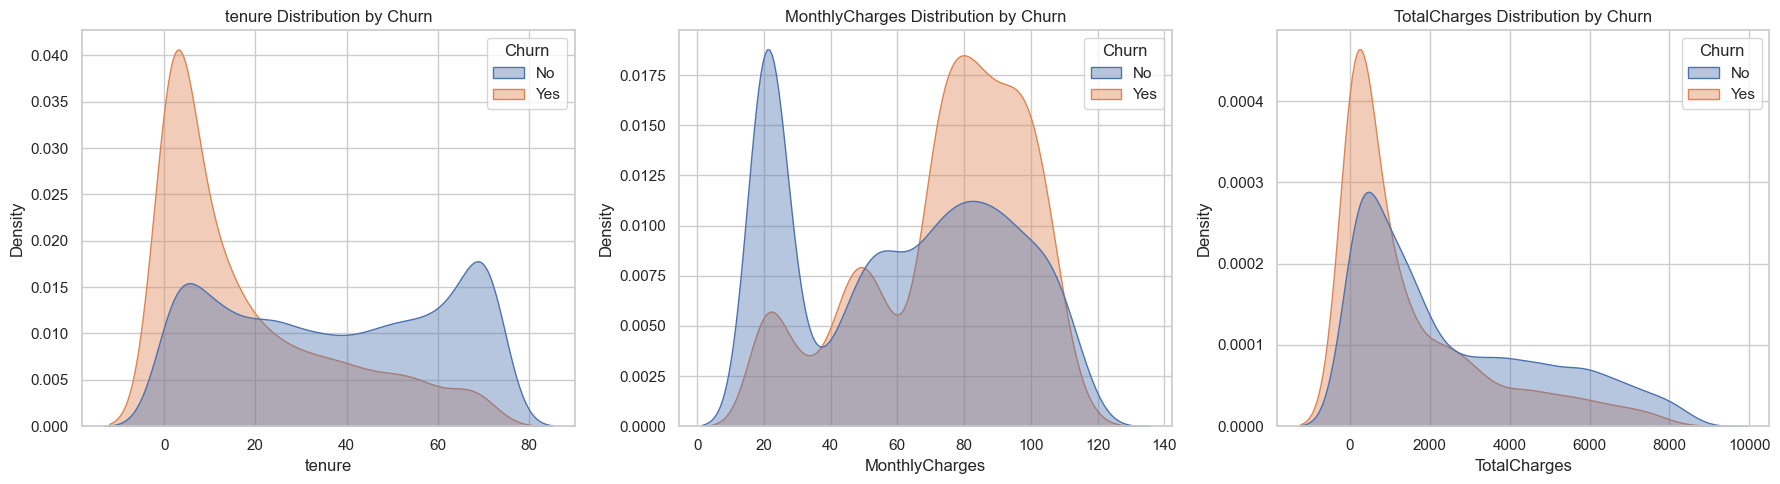

In [23]:
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, numeric_cols):
    sns.kdeplot(data=df_clean, x=col, hue='Churn', hue_order=['No', 'Yes'],
                palette=PALETTE, fill=True, common_norm=False, alpha=0.4, ax=ax)
    ax.set_title(f'{col} Distribution by Churn')
    ax.set_xlabel(col)
    ax.set_ylabel('Density')

plt.tight_layout()
plt.show()


C:\Users\amriy\AppData\Local\Temp\ipykernel_33712\2415806608.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Churn', y=col, order=['No', 'Yes'], palette=PALETTE, ax=ax)
C:\Users\amriy\AppData\Local\Temp\ipykernel_33712\2415806608.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Churn', y=col, order=['No', 'Yes'], palette=PALETTE, ax=ax)
C:\Users\amriy\AppData\Local\Temp\ipykernel_33712\2415806608.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Churn', y=col, order=['No', 'Yes']

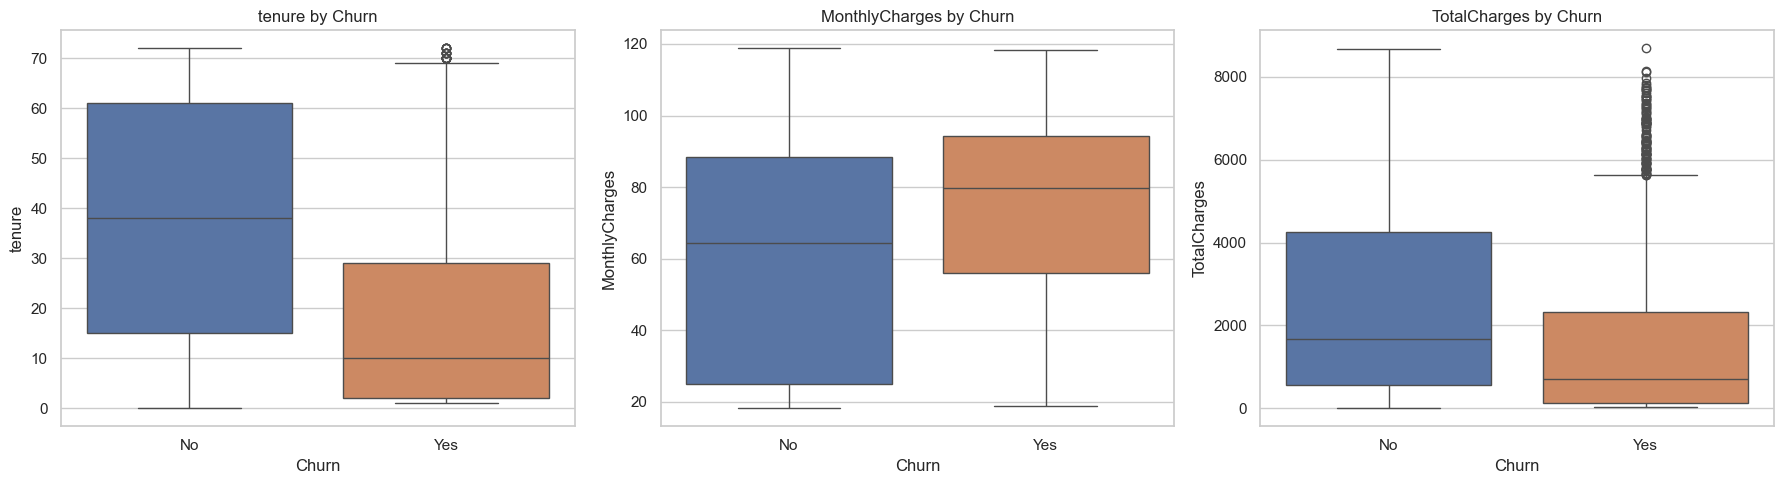

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(data=df_clean, x='Churn', y=col, order=['No', 'Yes'], palette=PALETTE, ax=ax)
    ax.set_title(f'{col} by Churn')

plt.tight_layout()
plt.show()


### Categorical Drivers of Churn

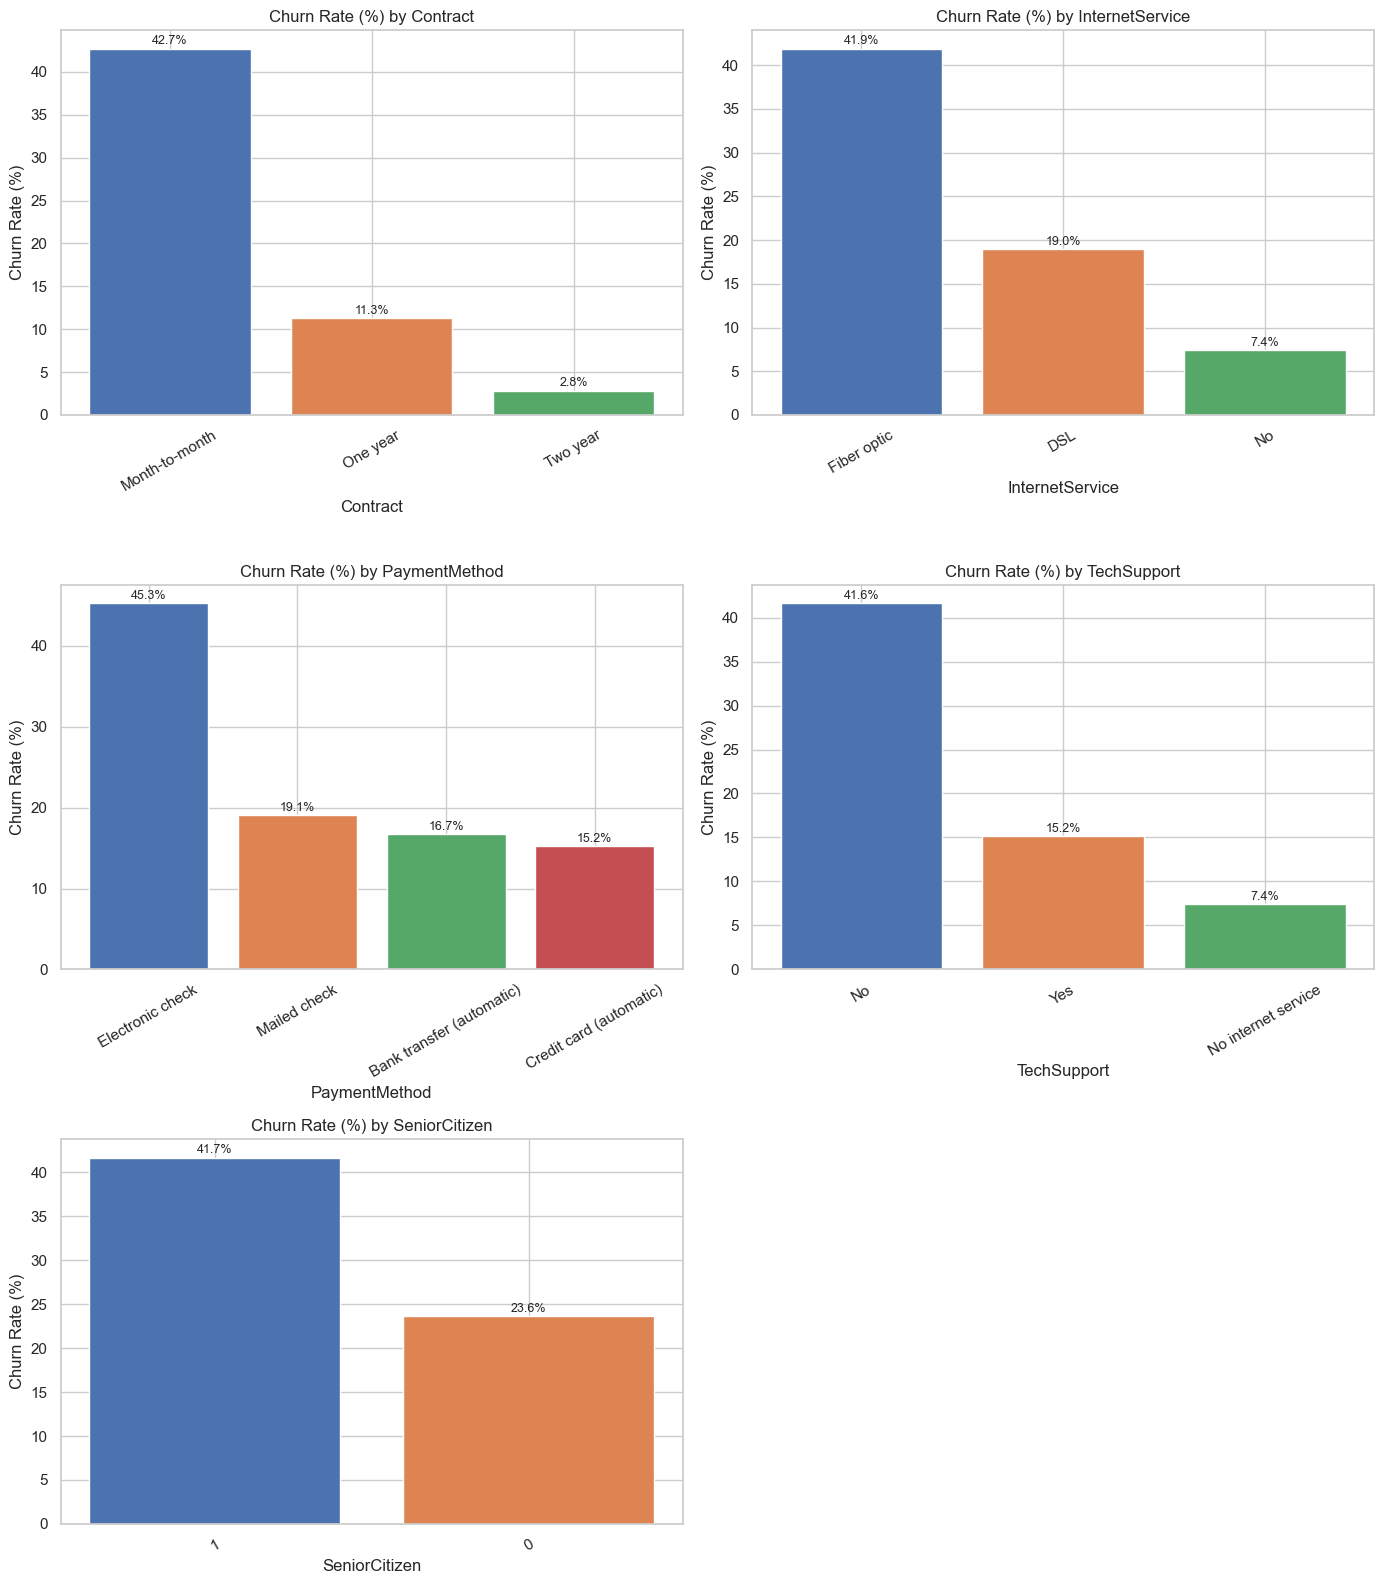

In [25]:
def churn_rate_by_category(df, col):
    rates = df.groupby(col, observed=True)['Churn'].apply(lambda s: (s == 'Yes').mean() * 100)
    return rates.sort_values(ascending=False)

cat_features = ['Contract', 'InternetService', 'PaymentMethod', 'TechSupport', 'SeniorCitizen']

fig, axes = plt.subplots(3, 2, figsize=(14, 16))
axes = axes.flatten()

for ax, col in zip(axes, cat_features):
    rates = churn_rate_by_category(df_clean, col)
    bars = ax.bar(rates.index.astype(str), rates.values, color=sns.color_palette('deep', len(rates)))
    ax.set_title(f'Churn Rate (%) by {col}')
    ax.set_ylabel('Churn Rate (%)')
    ax.set_xlabel(col)
    ax.tick_params(axis='x', rotation=30)
    for bar, val in zip(bars, rates.values):
        ax.text(bar.get_x() + bar.get_width() / 2, val + 0.5, f'{val:.1f}%', ha='center', fontsize=9)

axes[-1].axis('off')
plt.tight_layout()
plt.show()


### Correlation Analysis

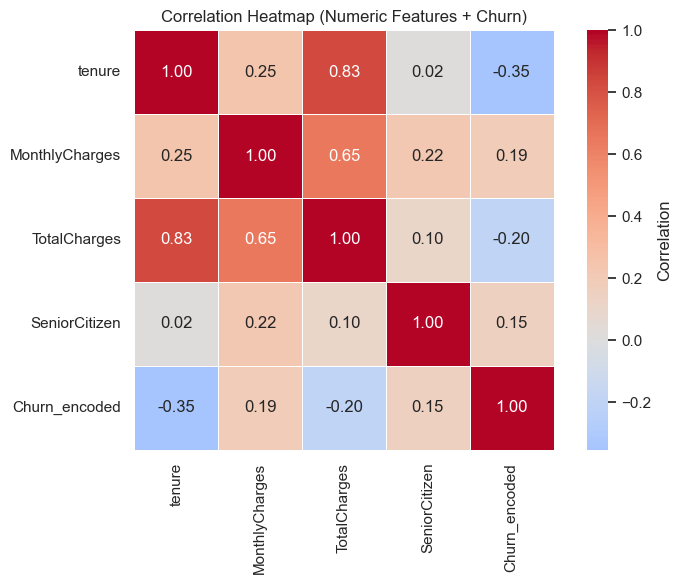

In [26]:
df_corr = df_clean.copy()
df_corr['Churn_encoded'] = (df_corr['Churn'] == 'Yes').astype(int)
df_corr['SeniorCitizen'] = df_corr['SeniorCitizen'].astype(int)

corr_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Churn_encoded']
corr_matrix = df_corr[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={'label': 'Correlation'})
plt.title('Correlation Heatmap (Numeric Features + Churn)')
plt.tight_layout()
plt.show()


### Top Features Associated with Churn

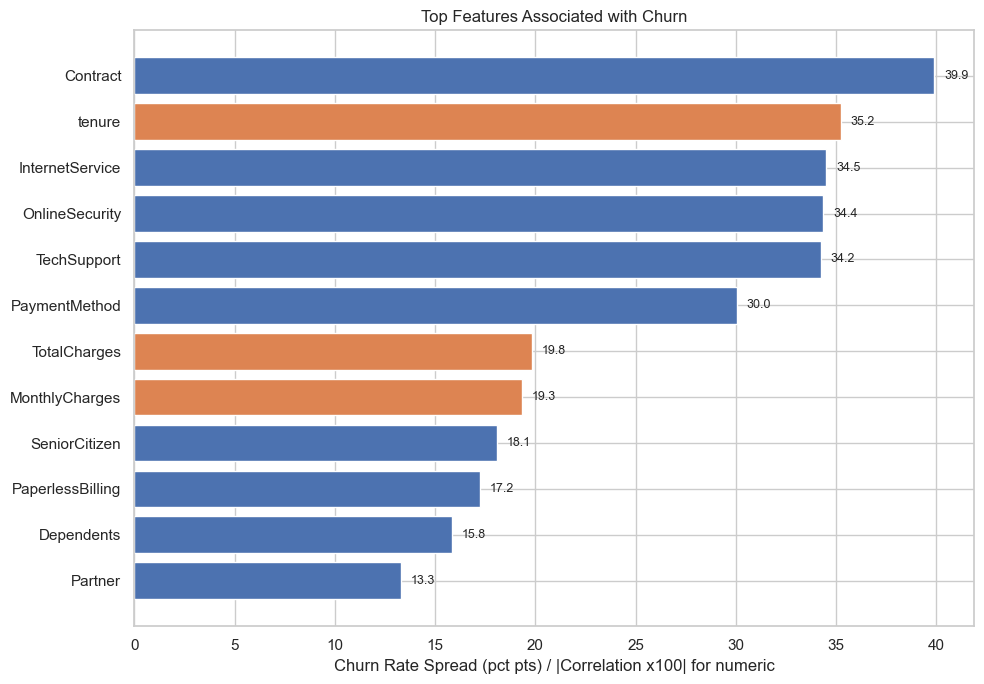

In [27]:
cat_encode_cols = ['Contract', 'InternetService', 'PaymentMethod', 'TechSupport', 'OnlineSecurity',
                    'PaperlessBilling', 'Dependents', 'Partner', 'SeniorCitizen']

churn_spread = {}
for col in cat_encode_cols:
    rates = df_clean.groupby(col, observed=True)['Churn'].apply(lambda s: (s == 'Yes').mean() * 100)
    churn_spread[col] = rates.max() - rates.min()

numeric_assoc = df_corr[['tenure', 'MonthlyCharges', 'TotalCharges']].corrwith(df_corr['Churn_encoded']).abs() * 100
for col, val in numeric_assoc.items():
    churn_spread[col] = val

ranked = pd.Series(churn_spread).sort_values(ascending=True)

plt.figure(figsize=(10, 7))
colors = ['#DD8452' if c in numeric_assoc.index else '#4C72B0' for c in ranked.index]
plt.barh(ranked.index, ranked.values, color=colors)
plt.xlabel('Churn Rate Spread (pct pts) / |Correlation x100| for numeric')
plt.title('Top Features Associated with Churn')
for i, v in enumerate(ranked.values):
    plt.text(v + 0.5, i, f'{v:.1f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()


### Customer Segmentation (K-Means)

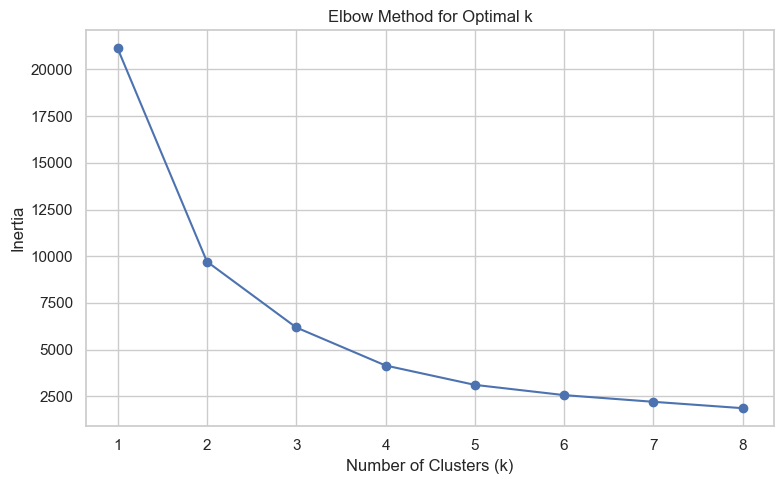

In [28]:
cluster_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
X = df_clean[cluster_features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertias = []
k_range = range(1, 9)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(k_range), inertias, marker='o', color='#4C72B0')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(list(k_range))
plt.tight_layout()
plt.show()


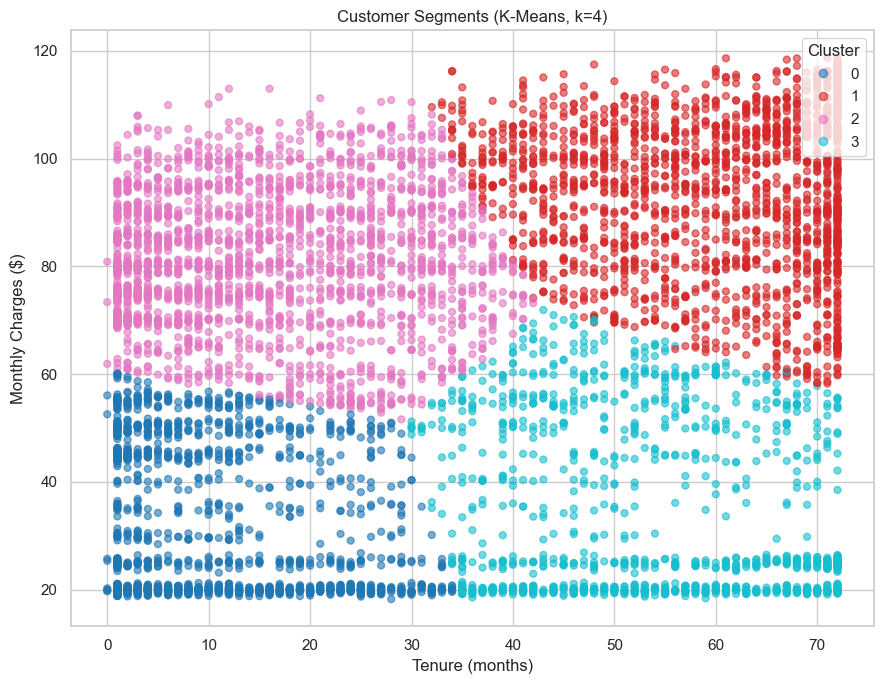

In [29]:
k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df_clean['Cluster'] = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(9, 7))
scatter = plt.scatter(df_clean['tenure'], df_clean['MonthlyCharges'], c=df_clean['Cluster'],
                       cmap='tab10', alpha=0.6, s=25)
plt.xlabel('Tenure (months)')
plt.ylabel('Monthly Charges ($)')
plt.title('Customer Segments (K-Means, k=4)')
plt.legend(*scatter.legend_elements(), title='Cluster', loc='upper right')
plt.tight_layout()
plt.show()


In [30]:
segment_summary = df_clean.groupby('Cluster').agg(
    avg_tenure=('tenure', 'mean'),
    avg_monthly_charges=('MonthlyCharges', 'mean'),
    avg_total_charges=('TotalCharges', 'mean'),
    churn_rate_pct=('Churn', lambda s: (s == 'Yes').mean() * 100),
    n_customers=('Churn', 'size')
).round(1).sort_values('churn_rate_pct')

segment_summary


,avg_tenure,avg_monthly_charges,avg_total_charges,churn_rate_pct,n_customers
Cluster,,,,,
3,53.6,34.9,1835.6,5.0,1160
1,59.5,93.3,5548.7,15.4,1904
0,10.2,31.8,302.2,24.7,1703
2,15.4,80.8,1251.2,48.2,2276


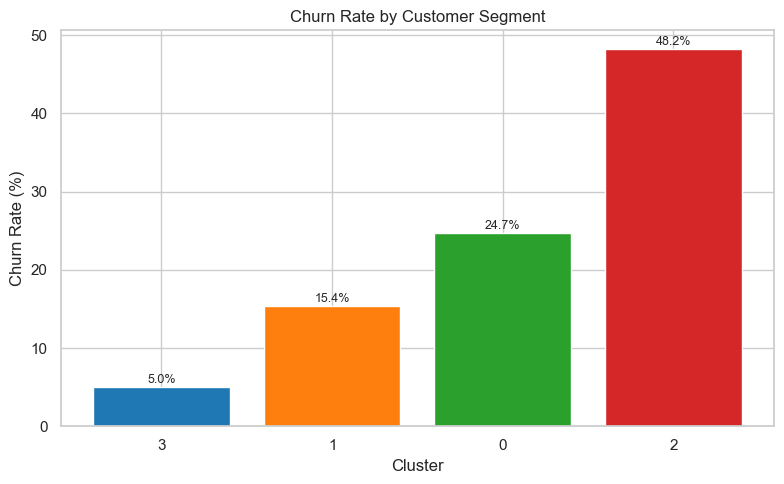

In [31]:
plt.figure(figsize=(8, 5))
bars = plt.bar(segment_summary.index.astype(str), segment_summary['churn_rate_pct'],
               color=sns.color_palette('tab10', k))
plt.xlabel('Cluster')
plt.ylabel('Churn Rate (%)')
plt.title('Churn Rate by Customer Segment')
for bar, val in zip(bars, segment_summary['churn_rate_pct']):
    plt.text(bar.get_x() + bar.get_width() / 2, val + 0.5, f'{val:.1f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.show()


### Key Insights Summary

## Task 2c: Predictive Model Development

In [32]:
df_clean = pd.read_csv('../data/cleaned_telco.csv')
df_clean['SeniorCitizen'] = df_clean['SeniorCitizen'].astype('category')
df_clean.shape


(7043, 20)

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, roc_curve, confusion_matrix, classification_report)
import joblib
import json


### Train/Test Split

In [34]:
X = df_clean.drop(columns=['Churn'])
y = (df_clean['Churn'] == 'Yes').astype(int)

numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_features = [c for c in X.columns if c not in numeric_features]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

X_train.shape, X_test.shape


((5634, 19), (1409, 19))

### Preprocessing

In [35]:
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])


### Model Training

- `class_weight='balanced'` used for both models — Task 2b showed churn is ~26.5% of customers, so an unweighted model would bias toward predicting the majority (non-churn) class

In [36]:
log_reg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(class_weight='balanced', n_estimators=300, random_state=42))
])

log_reg_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

### Model Evaluation

In [37]:
models = {'Logistic Regression': log_reg_pipeline, 'Random Forest': rf_pipeline}
results = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    results[name] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_proba),
        'y_pred': y_pred,
        'y_proba': y_proba
    }

results_df = pd.DataFrame({name: {k: v for k, v in r.items() if k not in ('y_pred', 'y_proba')}
                            for name, r in results.items()}).T
results_df


,accuracy,precision,recall,f1,roc_auc
Logistic Regression,0.738112,0.504303,0.783422,0.613613,0.841502
Random Forest,0.785664,0.628571,0.470588,0.538226,0.821836


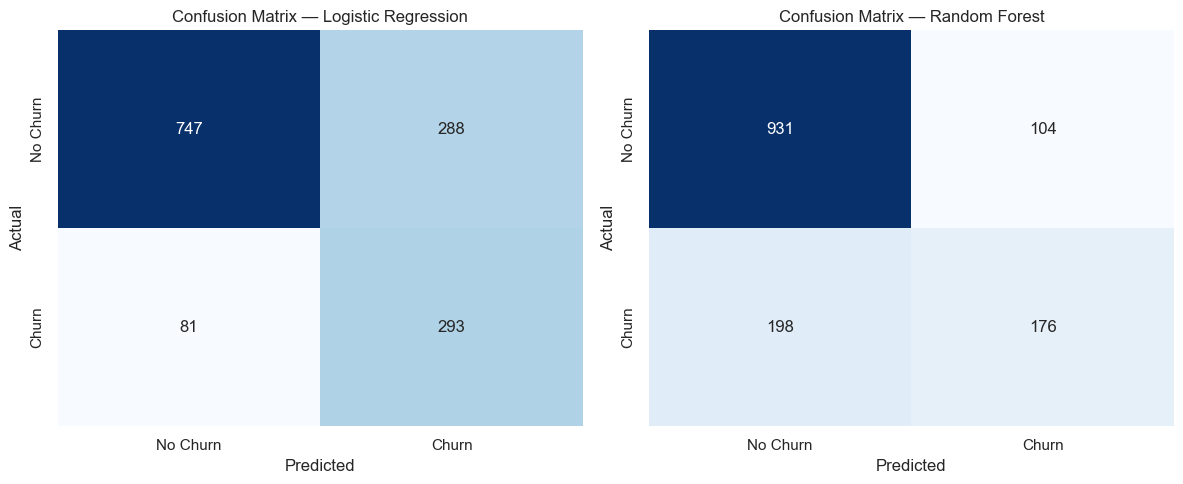

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, name in zip(axes, models.keys()):
    cm = confusion_matrix(y_test, results[name]['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'], ax=ax)
    ax.set_title(f'Confusion Matrix — {name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()


In [39]:
for name in models.keys():
    print(f'--- {name} ---')
    print(classification_report(y_test, results[name]['y_pred'], target_names=['No Churn', 'Churn']))


--- Logistic Regression ---
              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1035
       Churn       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

--- Random Forest ---
              precision    recall  f1-score   support

    No Churn       0.82      0.90      0.86      1035
       Churn       0.63      0.47      0.54       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.70      1409
weighted avg       0.77      0.79      0.77      1409



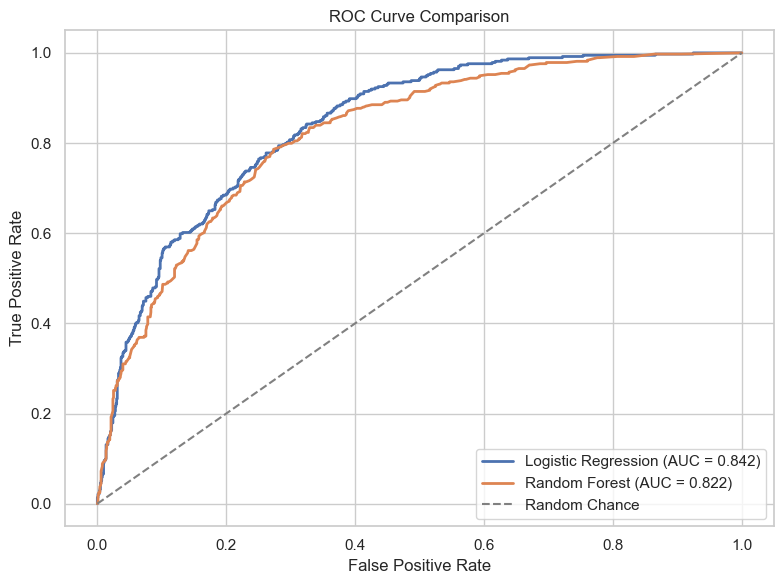

In [40]:
plt.figure(figsize=(8, 6))
for name in models.keys():
    fpr, tpr, _ = roc_curve(y_test, results[name]['y_proba'])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {results[name]['roc_auc']:.3f})", linewidth=2)

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


### Model Selection

In [41]:
best_model_name = results_df['roc_auc'].idxmax()
best_model_name, results_df.loc[best_model_name]


('Logistic Regression',
 accuracy     0.738112
 precision    0.504303
 recall       0.783422
 f1           0.613613
 roc_auc      0.841502
 Name: Logistic Regression, dtype: float64)

In [42]:
winning_pipeline = models[best_model_name]
best_metrics = results_df.loc[best_model_name]


- **Logistic Regression wins** on ROC-AUC (0.842 vs 0.822) and recall (0.783 vs 0.471) — the metrics that matter most given the churn class imbalance
- Random Forest has higher accuracy (0.786 vs 0.738) and precision (0.629 vs 0.504), but misses far more actual churners (recall 0.471), which is costly for a retention use case where failing to flag a churner is the expensive error

### Feature Importance

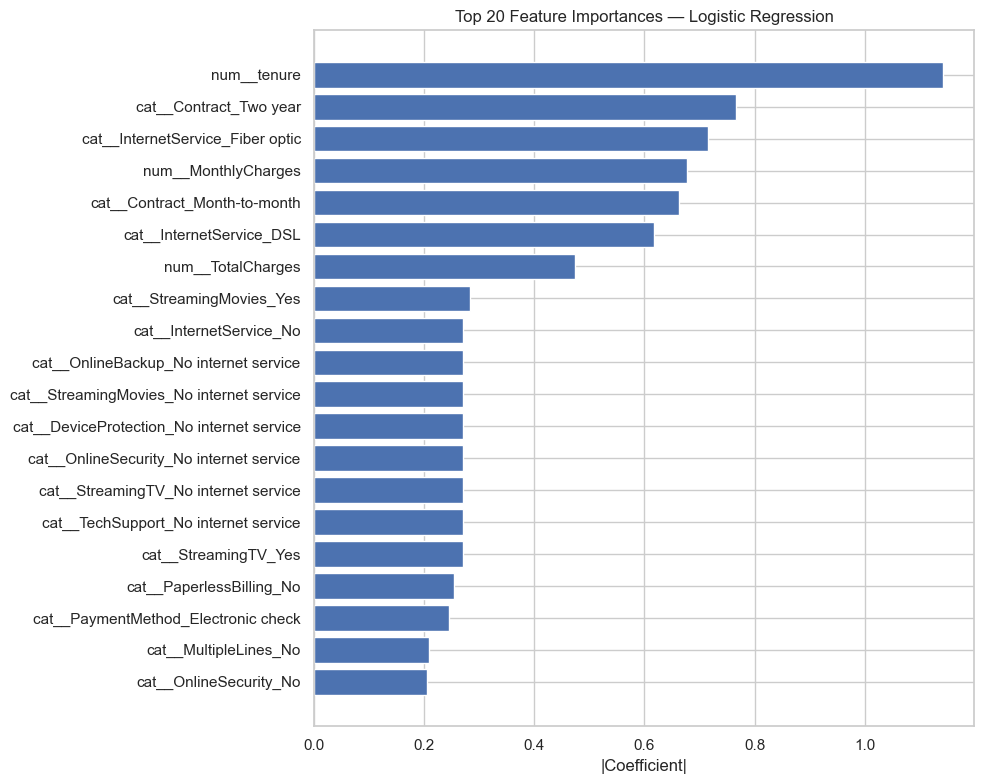

In [43]:
feature_names = winning_pipeline.named_steps['preprocessor'].get_feature_names_out()
classifier = winning_pipeline.named_steps['classifier']

if hasattr(classifier, 'feature_importances_'):
    importances = classifier.feature_importances_
    importance_label = 'Importance'
else:
    importances = np.abs(classifier.coef_[0])
    importance_label = '|Coefficient|'

importance_series = pd.Series(importances, index=feature_names).sort_values(ascending=True).tail(20)

plt.figure(figsize=(10, 8))
plt.barh(importance_series.index, importance_series.values, color='#4C72B0')
plt.xlabel(importance_label)
plt.title(f'Top 20 Feature Importances — {best_model_name}')
plt.tight_layout()
plt.show()


### Saving the Model

In [44]:
import os
os.makedirs('../models', exist_ok=True)

joblib.dump(winning_pipeline, '../models/churn_pipeline.pkl')


['../models/churn_pipeline.pkl']

In [45]:
sample_input = X_test.iloc[0].to_dict()
for k, v in sample_input.items():
    if isinstance(v, (np.integer,)):
        sample_input[k] = int(v)
    elif isinstance(v, (np.floating,)):
        sample_input[k] = float(v)
    elif hasattr(v, 'item'):
        sample_input[k] = v.item()

with open('../models/sample_input.json', 'w') as f:
    json.dump(sample_input, f, indent=2)

sample_input


{'gender': 'Male',
 'SeniorCitizen': 0,
 'Partner': 'Yes',
 'Dependents': 'Yes',
 'tenure': 72,
 'PhoneService': 'Yes',
 'MultipleLines': 'Yes',
 'InternetService': 'Fiber optic',
 'OnlineSecurity': 'Yes',
 'OnlineBackup': 'Yes',
 'DeviceProtection': 'Yes',
 'TechSupport': 'Yes',
 'StreamingTV': 'Yes',
 'StreamingMovies': 'Yes',
 'Contract': 'Two year',
 'PaperlessBilling': 'Yes',
 'PaymentMethod': 'Credit card (automatic)',
 'MonthlyCharges': 114.05,
 'TotalCharges': 8468.2}

### Final Model Summary

- **Final chosen model: Logistic Regression** (with ), selected over Random Forest based on ROC-AUC and recall
- Accuracy: **0.738**
- Precision: **0.504**
- Recall: **0.783**
- F1 Score: **0.614**
- ROC-AUC: **0.842**
- Full preprocessing + classifier pipeline saved to `models/churn_pipeline.pkl`
- One raw sample input row saved to `models/sample_input.json` for later FastAPI endpoint testing